# XGBoost–CNN Hybrid Model for Wind Speed Forecasting
## Multivariate Standalone Optimal Model with Residual Correction
### Sections: Original Model | Grid Search | Randomized Search | Optuna

**Methodology Overview:**
1. An XGBoost primary model (pre-tuned via Optuna) generates wind-speed forecasts.
2. The residuals from XGBoost are modelled by a 1-D CNN residual-correction network.
3. The hybrid forecast is: **Ŷ_hybrid = Ŷ_XGB + Ŷ_CNN_residual**
4. All hyperparameter searches use only the first 80% of data (training set) with
   `TimeSeriesSplit` cross-validation — the held-out last 20% is never seen during tuning.


## 1. Installing Required Packages

In [1]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 30.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
scikit-learn version: 1.8.0
scikeras version: 0.13.0


In [2]:
# INSTALLING REQUIRED PACKAGES
!pip install statsmodels optuna tabulate xgboost scikeras --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.4 MB/s eta 0:00:00


## 2. Imports & Global Settings

In [3]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from scipy.stats import randint, uniform

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (CNN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (scikit-learn API for Keras)
from scikeras.wrappers import KerasRegressor

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once; reused throughout) ──────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [4]:
# =============================================================================
# LOADING THE DATASET
# Dataset sources:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:", df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train–Test Split (80 / 20, Time-Based)

In [5]:
# =============================================================================
# Train-test split — first 80% for training, last 20% for testing.
# Temporal ordering is strictly preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Feature matrix
y = df['WS10M']                 # Target: wind speed (m/s)

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  (first {split_index} samples)")
print(f"Test set      : {X_test.shape}  (last {len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (first 3212 samples)
Test set      : (803, 13)  (last 803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. Shared Helper Functions

In [6]:
# =============================================================================
# Helper functions used by all model sections below.
# Defined once here to avoid repetition across sections.
# =============================================================================

def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual correction model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2


def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


## 6. XGBoost Primary Model (Optuna-Optimised Parameters)

The XGBoost model was previously optimised with Optuna and achieved the
following standalone wind-speed forecasting performance:

| Method | Train MSE | Test MSE | Train MAE | Test MAE | Train RMSE | Test RMSE | Train MAPE (%) | Test MAPE (%) | Train R² | Test R² |
|--------|-----------|----------|-----------|----------|------------|-----------|----------------|---------------|----------|---------|
| Optuna | 0.211530  | 0.527328 | 0.360631  | 0.551346 | 0.459923   | 0.726173  | 9.983644       | 14.987060     | 0.916036 | 0.781323|


In [7]:
# =============================================================================
# XGBoost Primary Model
# Best parameters sourced from prior Optuna optimisation run.
# The model is fitted on X_train only; predictions over the full dataset are
# stored so residuals can be computed for the CNN correction layer.
# =============================================================================

# Best Parameters: {'n_estimators': 300, 'max_depth': 6,
#   'learning_rate': 0.02017215364230889, 'min_child_weight': 5,
#   'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
Best_Parameters = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.02017215364230889,
    'gamma':            0.019237778052053844,
    'subsample':        0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (test set remains unseen until evaluation)
best_xgb.fit(X_train, y_train)
print(f"XGBoost fitted. Parameters: {Best_Parameters}")

# ── Train / Test predictions ──────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white", height=600
)
fig_table.show()


XGBoost fitted. Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2115  | Test MSE:  0.5273
Train MAE:  0.3606  | Test MAE:  0.5513
Train RMSE: 0.4599 | Test RMSE: 0.7262
Train MAPE: 9.9836%| Test MAPE: 14.9871%
Train R²:   0.9160  | Test R²:   0.7813


## 7. Full-Dataset XGBoost Predictions & Residual Computation

In [8]:
# =============================================================================
# Generate predictions over the FULL dataset to compute residuals.
# IMPORTANT:
#   - Train-set residuals are IN-SAMPLE  (used to train the CNN correction).
#   - Test-set residuals are OUT-OF-SAMPLE (used only for final evaluation).
# No test-set information leaks into the CNN training process.
# =============================================================================

# Predict on the full dataset
y_pred_full_xgb = best_xgb.predict(X)

# Attach predictions and residuals to the main dataframe
df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

print("Predictions and residuals added to dataframe.")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))
print(f"\nDataframe shape: {df.shape}")

# Backup the enriched dataframe — this is the master reference for all hybrid models
df_backup = df.copy()

# ── Visualise actual vs predicted + residuals ─────────────────────────────────
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (XGB Optuna)", "Residuals"),
    shared_xaxes=True,
    vertical_spacing=0.12
)
# Plot 1: Actual vs Predicted
fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (XGB Optuna)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)
# Plot 2: Residuals
fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost Optuna — Full Dataset Predictions & Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Predictions and residuals added to dataframe.
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75         4.469862  0.280138
2013-01-04   5.74         5.277423  0.462577
2013-01-05   5.79         5.620399  0.169601
2013-01-06   4.52         5.237511 -0.717511
2013-01-07   4.66         4.876992 -0.216992
2013-01-08   3.61         3.838809 -0.228809
2013-01-09   4.19         4.121636  0.068364
2013-01-10   5.41         4.998459  0.411541
2013-01-11   5.95         4.748426  1.201574
2013-01-12   5.80         5.402409  0.397591

Dataframe shape: (4015, 16)



Saved to 'XGB_Primary_Model_Prediction.csv'


## 8. CNN Residual Correction Model — Data Preparation

The 1-D CNN is trained to predict the residuals left by XGBoost.
The final hybrid forecast is:  **Ŷ_hybrid = Ŷ_XGB + Ŷ_CNN_residual**

**Input format for Conv1D:** Each sample is reshaped to `(samples, 1, features)`
using `np.expand_dims`, treating each observation as a single time-step window.
This format is consistent across all four model variants below.

Features used for residual correction are selected based on domain knowledge
and prior feature-importance analysis.


In [9]:
# =============================================================================
# RESIDUAL CORRECTION MODEL — feature set for CNN
# =============================================================================

cnn_features = [
    'WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin',
    'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1',
    'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP',
    'SL_PRESSURE_lag1', 'CLOUD_COVER'
]

X_res = df[cnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: XGBoost residuals

# Same 80 / 20 temporal split as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res = X_res.iloc[:split_index_res]
y_train_res = y_res.iloc[:split_index_res]
X_test_res  = X_res.iloc[split_index_res:]
y_test_res  = y_res.iloc[split_index_res:]

print(f"CNN residual correction — training samples : {X_train_res.shape[0]}")
print(f"CNN residual correction — test samples     : {X_test_res.shape[0]}")
print(f"Number of input features                   : {X_train_res.shape[1]}")


CNN residual correction — training samples : 3212
CNN residual correction — test samples     : 803
Number of input features                   : 13


## 9. CNN Residual Correction — Original Model (No Hyperparameter Optimisation)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.2196 - val_loss: 0.2558
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1982 - val_loss: 0.2530
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1936 - val_loss: 0.2521
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1906 - val_loss: 0.2515
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1883 - val_loss: 0.2517
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1861 - val_loss: 0.2518
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1843 - val_loss: 0.2519
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1826 - val_loss: 0.2522
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1811 - val_loss: 0.2527
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1800 - val_loss: 0.2529
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1781 - val_loss: 0.2536
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

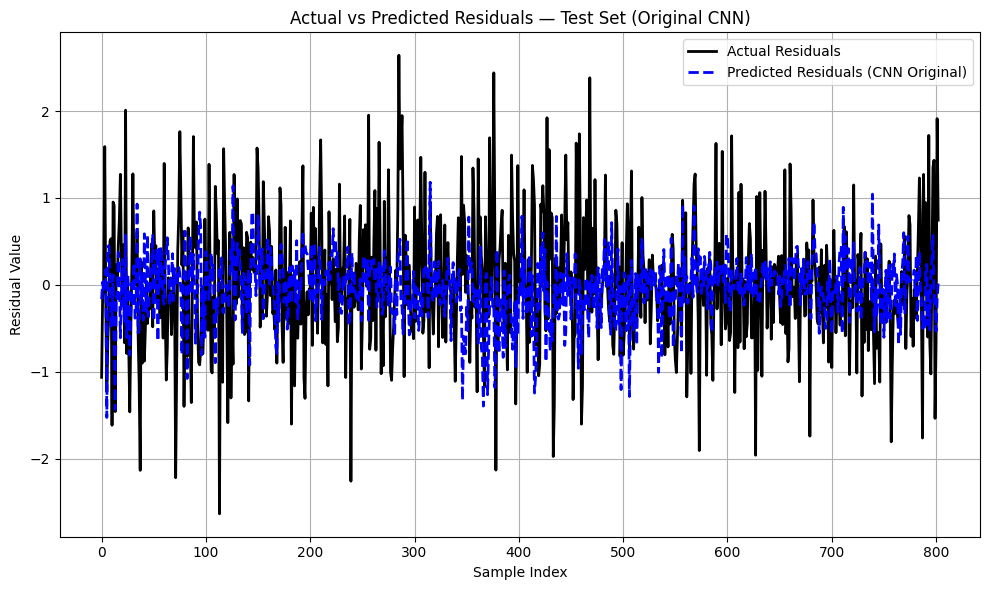

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== Hybrid XGB-CNN (Original) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.3720
MSE:  0.1384
MAE:  0.2759
MAPE: 7.2924%
R²:   0.9451

--- Test Metrics ---
RMSE: 0.7958
MSE:  0.6333
MAE:  0.6164
MAPE: 16.5435%
R²:   0.7374


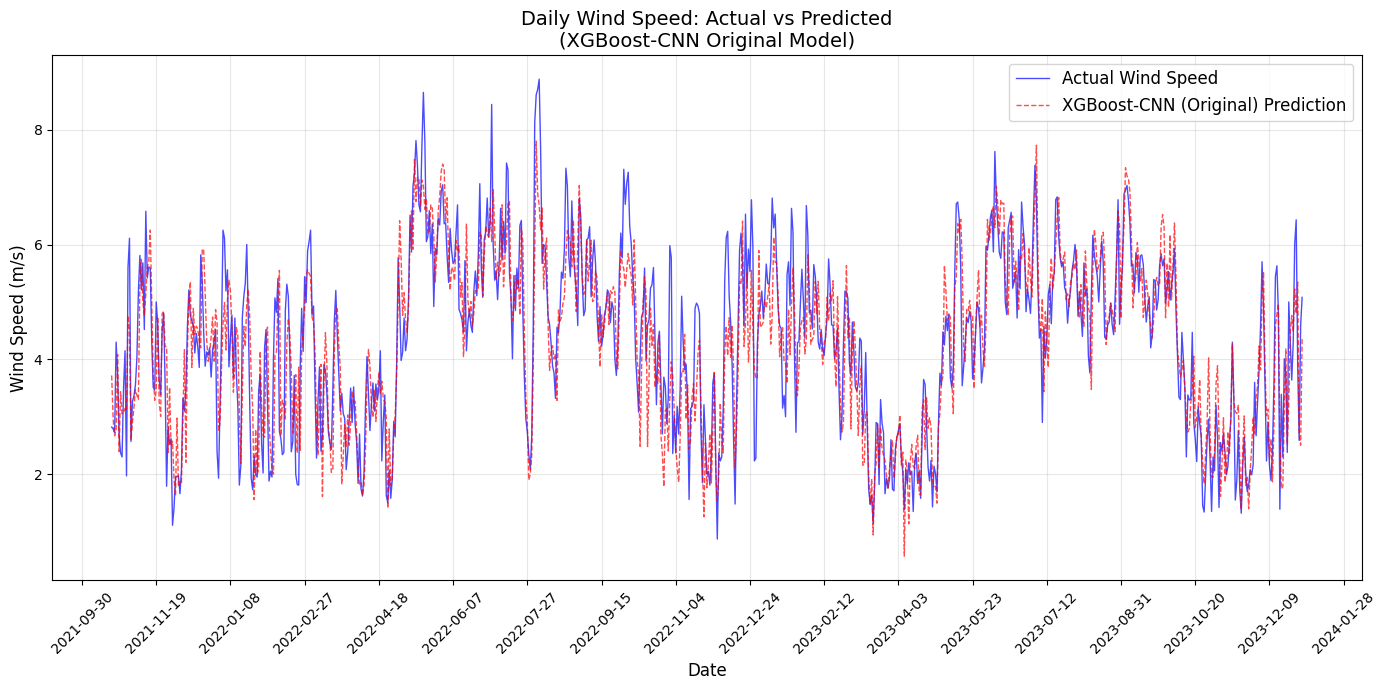

Saved to 'xgb_cnn_df_original.csv'


In [ ]:
# =============================================================================
# Section 1 — Original CNN model
# Default architecture: Conv1D (64 filters) → Flatten → Dense(50) → Dense(1).
# No hyperparameter search is performed in this section.
# Scaling is fit on training data only to prevent data leakage.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_original      = StandardScaler()
X_train_sc_orig      = scaler_original.fit_transform(X_train_res)
X_test_sc_orig       = scaler_original.transform(X_test_res)

# ── Reshape to Conv1D format: (samples, timesteps=1, features) ───────────────
X_train_cnn_orig     = np.expand_dims(X_train_sc_orig, axis=1)
X_test_cnn_orig      = np.expand_dims(X_test_sc_orig,  axis=1)
y_train_cnn_orig     = y_train_res.values
y_test_cnn_orig      = y_test_res.values

# ── Build CNN model ───────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)
model_orig = Sequential([
    # Conv1D expects input shape = (timesteps, features)
    Conv1D(filters=64, kernel_size=1, activation='relu',
           input_shape=(X_train_cnn_orig.shape[1], X_train_cnn_orig.shape[2])),
    Flatten(),           # Flatten before Dense layers
    Dense(50, activation='relu'),
    Dense(1)             # Regression output layer
])
model_orig.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Fit on training residuals only (validation_split uses last 20% of train
# chronologically — no test-set leakage)
history_orig = model_orig.fit(
    X_train_cnn_orig, y_train_cnn_orig,
    epochs=100,
    batch_size=32,
    validation_split=0.2,   # Uses last 20% of training data as validation
    verbose=1,
    shuffle=False            # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_orig = model_orig.predict(X_train_cnn_orig).flatten()
y_test_pred_orig  = model_orig.predict(X_test_cnn_orig).flatten()

print("\n--- Original CNN Residual Model Evaluation ---")
evaluate(y_train_cnn_orig, y_train_pred_orig, label="Train (CNN Original)")
evaluate(y_test_cnn_orig,  y_test_pred_orig,  label="Test  (CNN Original)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_cnn_orig,  label='Actual Residuals',  color='black', linewidth=2)
plt.plot(y_test_pred_orig, label='Predicted Residuals (CNN Original)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Original CNN)')
plt.xlabel('Sample Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_orig               = scaler_original.transform(X_res)
X_full_cnn_orig              = np.expand_dims(X_full_sc_orig, axis=1)
full_pred_residuals_original  = model_orig.predict(X_full_cnn_orig).flatten()

df_backup['predicted_residuals_cnn_original'] = full_pred_residuals_original

# ── Hybrid prediction: XGB + CNN residual correction ─────────────────────────
# FIX: original code used 'Pred_XGB_Optuna ' (trailing space) — corrected here
df_backup['XGB_cnn_Original'] = (df_backup['Pred_XGB_Optuna'] +
                                  df_backup['predicted_residuals_cnn_original'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_orig = df_backup.iloc[:split_index_res].copy()
test_df_orig  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-CNN (Original) Performance on WS10M ===")
train_metrics_orig = evaluate_performance(
    train_df_orig['WS10M'], train_df_orig['XGB_cnn_Original'], set_name="Train")
test_metrics_orig  = evaluate_performance(
    test_df_orig['WS10M'],  test_df_orig['XGB_cnn_Original'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_orig.index = pd.to_datetime(test_df_orig.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_orig.index, test_df_orig['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_orig.index, test_df_orig['XGB_cnn_Original'],
         label='XGBoost-CNN (Original) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-CNN Original Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_cnn_original_df = df_backup[cnn_features + ['WS10M', 'XGB_cnn_Original']]
xgb_cnn_original_df.to_csv('xgb_cnn_df_original.csv', index=True)
print("Saved to 'xgb_cnn_df_original.csv'")


## 10. CNN Residual Correction — Grid Search Hyperparameter Optimisation

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.01; total time=   8.4s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.01; total time=   9.3s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.01; total time=  14.6s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.01; total time=  17.5s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.01; total time=  23.3s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.001; total time=   7.4s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, model__filters=32, model__learning_rate=0.001; total time=  12.4s
[CV] END batch_size=16, epochs=50, model__dropout_rate=0.1, 

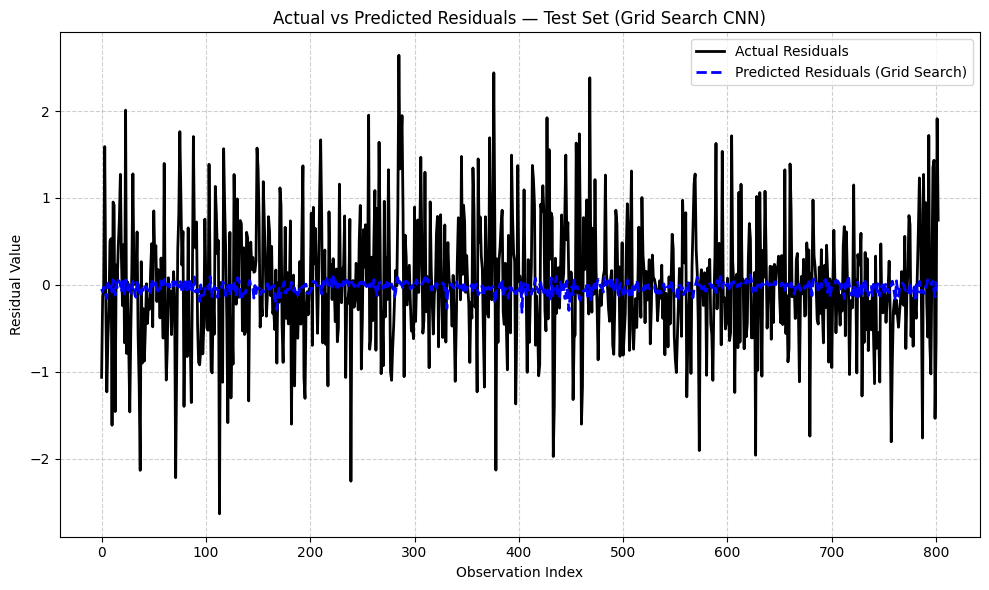


=== Hybrid XGB-CNN (Grid Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4539
MSE:  0.2061
MAE:  0.3555
MAPE: 9.6287%
R²:   0.9182

--- Test Metrics ---
RMSE: 0.7263
MSE:  0.5275
MAE:  0.5516
MAPE: 14.7938%
R²:   0.7813


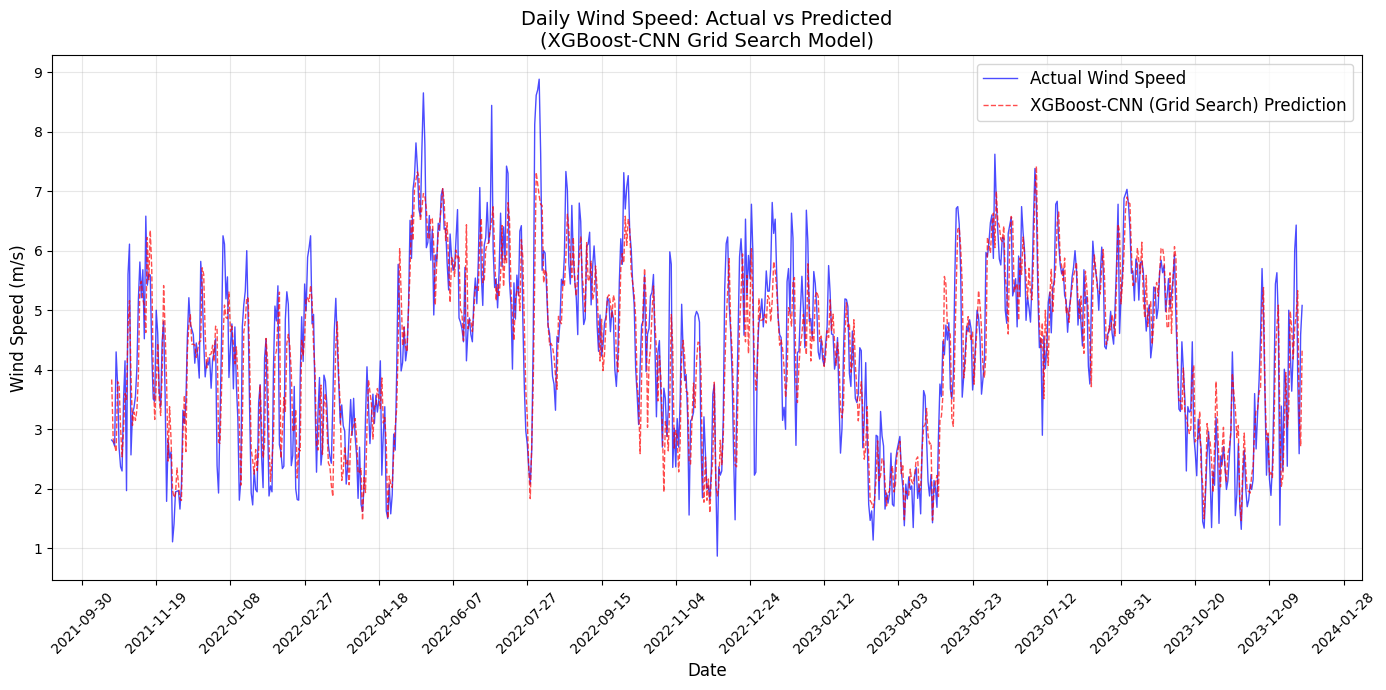

Saved to 'xgb_cnn_df_grid.csv'


In [ ]:
# =============================================================================
# Section 2 — Grid Search CNN
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on the training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIX vs original code:
#   - Replaced mid-notebook CSV reload (which broke the in-memory pipeline)
#     with the in-memory df_backup object.
#   - Fixed 'Pred_XGB_Optuna ' (trailing space KeyError) → 'Pred_XGB_Optuna'.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_grid      = StandardScaler()
X_train_sc_grid  = scaler_grid.fit_transform(X_train_res)
X_test_sc_grid   = scaler_grid.transform(X_test_res)

# ── Reshape to Conv1D format: (samples, timesteps=1, features) ───────────────
X_train_cnn_grid = np.expand_dims(X_train_sc_grid, axis=1)
X_test_cnn_grid  = np.expand_dims(X_test_sc_grid,  axis=1)

# ── CNN model builder function (required by KerasRegressor) ──────────────────
def build_cnn_grid(filters=64, kernel_size=1, dropout_rate=0.2, learning_rate=0.001):
    """Builds and compiles a 1-D CNN model for use in GridSearchCV."""
    n_features = X_train_cnn_grid.shape[2]
    mdl = Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
               input_shape=(1, n_features)),
        Flatten(),
        Dropout(dropout_rate),
        Dense(50, activation='relu'),
        Dense(1)
    ])
    mdl.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
cnn_regressor_grid = KerasRegressor(
    model=build_cnn_grid, verbose=0, random_state=RANDOM_SEED
)

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    'model__filters':       [32, 64, 128],
    'model__dropout_rate':  [0.1, 0.2, 0.3],
    'model__learning_rate': [1e-2, 1e-3, 1e-4],
    'batch_size':           [16, 32],
    'epochs':               [50, 100]
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_grid = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=cnn_regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv_grid,           # TimeSeriesSplit preserves temporal ordering
    verbose=2,
    n_jobs=1                # Sequential — parallelism with TF can cause issues
)

# Fit grid search on training data only
grid_search.fit(X_train_cnn_grid, y_train_res.values)

best_cnn_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_grid = best_cnn_grid.predict(X_train_cnn_grid).flatten()
y_test_pred_grid  = best_cnn_grid.predict(X_test_cnn_grid).flatten()

print("\n--- Grid Search CNN Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_grid, label="Train (CNN Grid Search)")
evaluate(y_test_res.values,  y_test_pred_grid,  label="Test  (CNN Grid Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search CNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_grid          = scaler_grid.transform(X_res)
X_full_cnn_grid         = np.expand_dims(X_full_sc_grid, axis=1)
full_pred_residuals_grid = best_cnn_grid.predict(X_full_cnn_grid).flatten()

df_backup['predicted_residuals_cnn_grid'] = full_pred_residuals_grid

# ── Hybrid prediction: XGB + CNN residual correction ─────────────────────────
df_backup['XGB_cnn_grid'] = (df_backup['Pred_XGB_Optuna'] +
                              df_backup['predicted_residuals_cnn_grid'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_grid = df_backup.iloc[:split_index_res].copy()
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-CNN (Grid Search) Performance on WS10M ===")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_cnn_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_cnn_grid'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_cnn_grid'],
         label='XGBoost-CNN (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-CNN Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_cnn_df_grid = df_backup[cnn_features + ['WS10M', 'XGB_cnn_grid']]
xgb_cnn_df_grid.to_csv('xgb_cnn_df_grid.csv', index=True)
print("Saved to 'xgb_cnn_df_grid.csv'")


## 11. CNN Residual Correction — Randomized Search Hyperparameter Optimisation

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__filters=126, model__learning_rate=0.007117219002454924; total time=   9.2s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__filters=126, model__learning_rate=0.007117219002454924; total time=  11.5s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__filters=126, model__learning_rate=0.007117219002454924; total time=  13.9s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__filters=126, model__learning_rate=0.007117219002454924; total time=  15.7s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__filters=126, model__learning_rate=0.007117219002454924; total time=  19.3s
[CV] END batch_size=36, epochs=132, model__dropout_rate=0.12999247474540088, model__filters=107, model__learning_rate=0.003103377500251196; tota

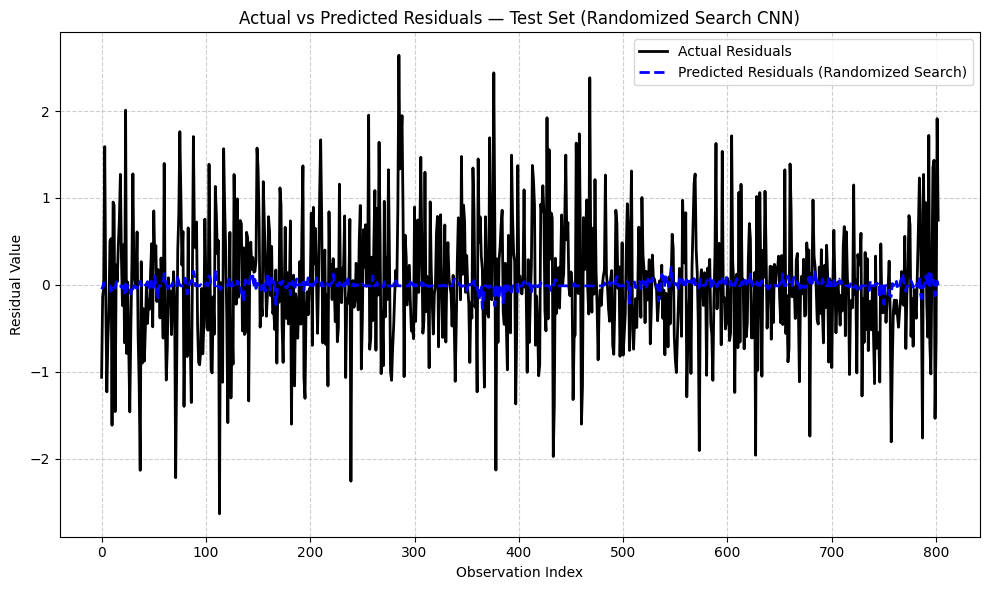


=== Hybrid XGB-CNN (Randomized Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4482
MSE:  0.2009
MAE:  0.3523
MAPE: 9.7173%
R²:   0.9203

--- Test Metrics ---
RMSE: 0.7240
MSE:  0.5242
MAE:  0.5497
MAPE: 14.9216%
R²:   0.7826


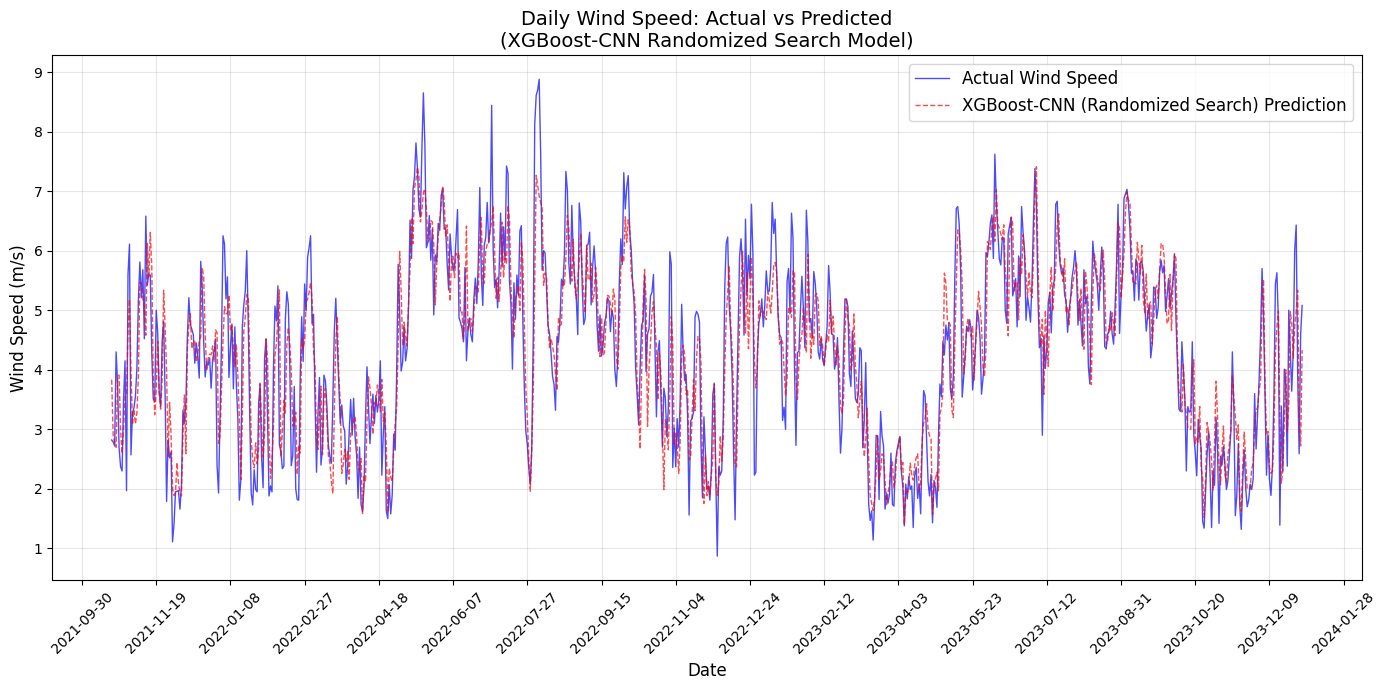

Saved to 'xgb_cnn_df_random.csv'


In [ ]:
# =============================================================================
# Section 3 — Randomized Search CNN
# Random sampling over hyperparameter distributions (10 iterations).
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIX vs original code:
#   - Replaced cv=3 (standard K-Fold, shuffles data) with
#     TimeSeriesSplit(n_splits=5) to respect temporal ordering.
#   - Fixed 'Pred_XGB_Optuna ' (trailing space KeyError) → 'Pred_XGB_Optuna'.
#   - param_dist keys corrected to use 'model__' prefix required by scikeras.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_random     = StandardScaler()
X_train_sc_rand   = scaler_random.fit_transform(X_train_res)
X_test_sc_rand    = scaler_random.transform(X_test_res)

# ── Reshape to Conv1D format: (samples, timesteps=1, features) ───────────────
X_train_cnn_rand  = np.expand_dims(X_train_sc_rand, axis=1)
X_test_cnn_rand   = np.expand_dims(X_test_sc_rand,  axis=1)

# ── CNN model builder function (required by KerasRegressor) ──────────────────
def create_cnn_random(filters=64, dropout_rate=0.2, learning_rate=0.001):
    """Builds and compiles a 1-D CNN model for use in RandomizedSearchCV."""
    n_features = X_train_cnn_rand.shape[2]
    mdl = Sequential([
        Conv1D(filters=filters, kernel_size=1, activation='relu',
               input_shape=(1, n_features)),
        Flatten(),
        Dropout(dropout_rate),
        Dense(50, activation='relu'),
        Dense(1)    # Regression output
    ])
    mdl.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
cnn_regressor_rand = KerasRegressor(
    model=create_cnn_random, verbose=0, random_state=RANDOM_SEED
)

# ── Hyperparameter distributions ─────────────────────────────────────────────
param_dist = {
    'model__filters':       randint(20, 151),
    'model__dropout_rate':  uniform(0.1, 0.3),
    'model__learning_rate': uniform(1e-4, 9e-3),
    'batch_size':           randint(16, 65),
    'epochs':               randint(50, 151)
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_rand = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=cnn_regressor_rand,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=tscv_rand,           # TimeSeriesSplit preserves temporal ordering
    random_state=RANDOM_SEED,
    verbose=2,
    n_jobs=1                # Sequential — parallelism with TF can cause issues
)

# Fit randomized search on training data only
random_search.fit(X_train_cnn_rand, y_train_res.values)

best_cnn_rand = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_rand = best_cnn_rand.predict(X_train_cnn_rand).flatten()
y_test_pred_rand  = best_cnn_rand.predict(X_test_cnn_rand).flatten()

print("\n--- Randomized Search CNN Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_rand, label="Train (CNN Randomized Search)")
evaluate(y_test_res.values,  y_test_pred_rand,  label="Test  (CNN Randomized Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_rand,  label='Predicted Residuals (Randomized Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Randomized Search CNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_rand           = scaler_random.transform(X_res)
X_full_cnn_rand          = np.expand_dims(X_full_sc_rand, axis=1)
full_pred_residuals_rand  = best_cnn_rand.predict(X_full_cnn_rand).flatten()

df_backup['predicted_residuals_cnn_random'] = full_pred_residuals_rand

# ── Hybrid prediction: XGB + CNN residual correction ─────────────────────────
df_backup['XGB_cnn_random'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_cnn_random'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_rand = df_backup.iloc[:split_index_res].copy()
test_df_rand  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-CNN (Randomized Search) Performance on WS10M ===")
train_metrics_rand = evaluate_performance(
    train_df_rand['WS10M'], train_df_rand['XGB_cnn_random'], set_name="Train")
test_metrics_rand  = evaluate_performance(
    test_df_rand['WS10M'],  test_df_rand['XGB_cnn_random'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_rand.index = pd.to_datetime(test_df_rand.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_rand.index, test_df_rand['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_rand.index, test_df_rand['XGB_cnn_random'],
         label='XGBoost-CNN (Randomized Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-CNN Randomized Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_cnn_df_random = df_backup[cnn_features + ['WS10M', 'XGB_cnn_random']]
xgb_cnn_df_random.to_csv('xgb_cnn_df_random.csv', index=True)
print("Saved to 'xgb_cnn_df_random.csv'")


## 12. CNN Residual Correction — Optuna Bayesian Optimisation


Best Trial:
FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.23148933992177997], datetime_start=datetime.datetime(2026, 3, 13, 3, 15, 44, 311339), datetime_complete=datetime.datetime(2026, 3, 13, 3, 17, 35, 212219), params={'filters': 69, 'dropout_rate': 0.4802857225639665, 'learning_rate': 0.0029106359131330704, 'batch_size': 16, 'epochs': 55}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'filters': IntDistribution(high=150, log=False, low=20, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'learning_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32, 64)), 'epochs': IntDistribution(high=150, log=False, low=50, step=1)}, trial_id=0, value=None)

Best Parameters (Optuna):
{'filters': 69, 'dropout_rate': 0.4802857225639665, 'learning_rate': 0.0029106359131330704, 'batch_size': 16, 'epochs': 55}
Epoch 1/55
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 

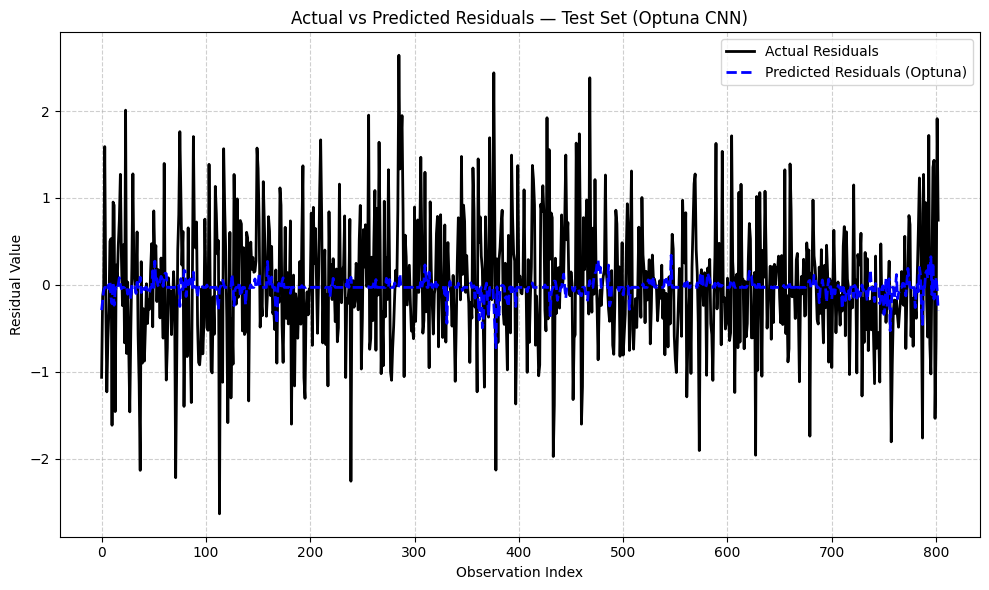

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== Hybrid XGB-CNN (Optuna) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4411
MSE:  0.1946
MAE:  0.3469
MAPE: 9.4328%
R²:   0.9228

--- Test Metrics ---
RMSE: 0.7265
MSE:  0.5277
MAE:  0.5524
MAPE: 14.7756%
R²:   0.7812


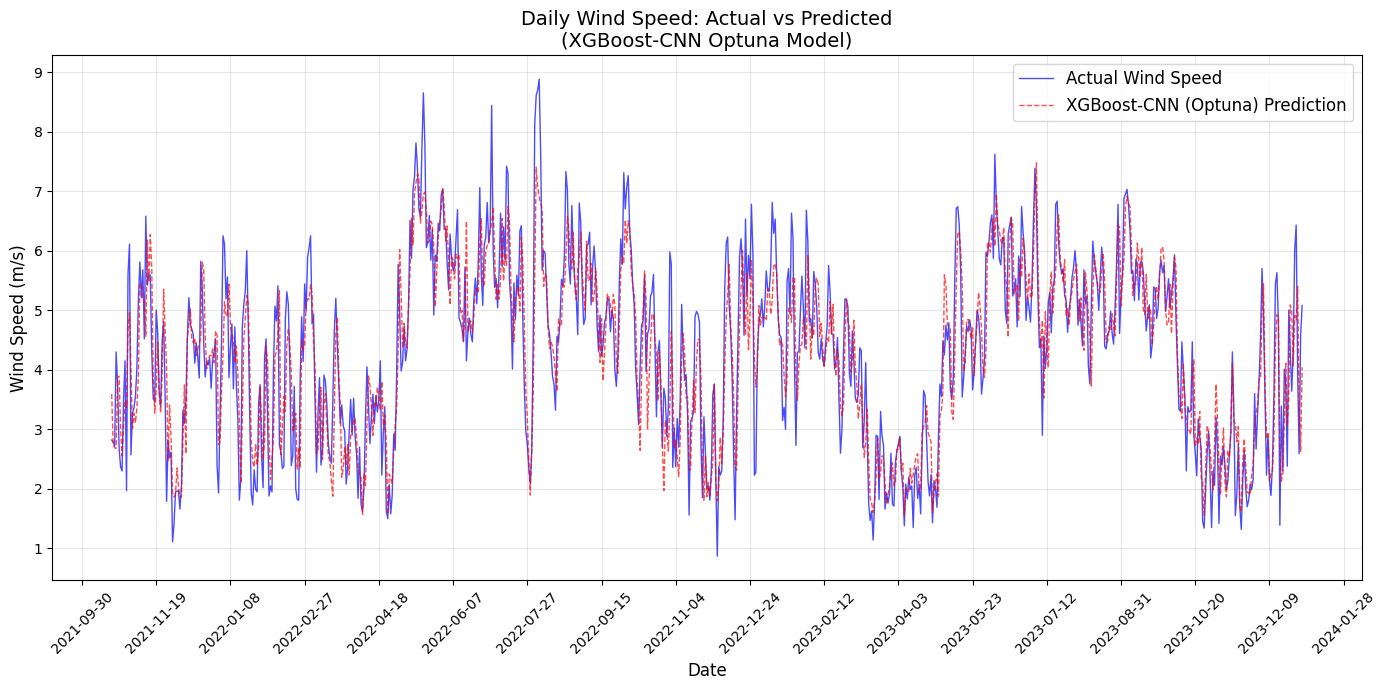

Saved to 'xgb_cnn_df_optuna.csv'


In [10]:
# =============================================================================
# Section 4 — Optuna CNN
# Bayesian (TPE) hyperparameter search over architecture and training params.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIXES vs original code:
#   1. suggest_loguniform() is DEPRECATED in Optuna ≥ 3.x.
#      Replaced with suggest_float('learning_rate', ..., log=True).
#   2. The original code built the CNN model ONCE in create_cnn_model() and
#      called model.fit() multiple times within the CV loop — this accumulates
#      weights across folds (weight leakage between folds).
#      Fixed: a FRESH model is rebuilt for every fold inside the objective.
#   3. Pre-scaled numpy array (X_train_sc_opt) is used throughout the
#      objective so the CNN always sees the same scaled input.
#   4. Fixed 'Pred_XGB_Optuna ' (trailing space KeyError) → 'Pred_XGB_Optuna'.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_optuna     = StandardScaler()
X_train_sc_opt    = scaler_optuna.fit_transform(X_train_res)
X_test_sc_opt     = scaler_optuna.transform(X_test_res)

# ── Reshape to Conv1D format: (samples, timesteps=1, features) ───────────────
X_train_cnn_opt   = np.expand_dims(X_train_sc_opt, axis=1)
X_test_cnn_opt    = np.expand_dims(X_test_sc_opt,  axis=1)
n_features_opt    = X_train_cnn_opt.shape[2]

# ── Optuna objective function ─────────────────────────────────────────────────
def cnn_objective(trial):
    """
    Objective for Optuna Bayesian optimisation.
    A FRESH model is rebuilt for every cross-validation fold to prevent
    gradient / weight accumulation across folds (weight leakage).
    """
    filters       = trial.suggest_int('filters', 20, 150)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs        = trial.suggest_int('epochs', 50, 150)

    tscv       = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X_train_cnn_opt):
        # Use pre-scaled numpy slices (no double-scaling / leakage)
        X_t = X_train_cnn_opt[train_idx]
        X_v = X_train_cnn_opt[val_idx]
        y_t = y_train_res.values[train_idx]
        y_v = y_train_res.values[val_idx]

        # Build a FRESH model for each fold to prevent weight accumulation
        tf.random.set_seed(RANDOM_SEED)
        fold_model = Sequential([
            Conv1D(filters=filters, kernel_size=1, activation='relu',
                   input_shape=(1, n_features_opt)),
            Flatten(),
            Dropout(dropout_rate),
            Dense(50, activation='relu'),
            Dense(1)
        ])
        fold_model.compile(loss='mse',
                           optimizer=Adam(learning_rate=learning_rate))
        fold_model.fit(X_t, y_t, epochs=epochs, batch_size=batch_size,
                       verbose=0, shuffle=False)

        preds = fold_model.predict(X_v, verbose=0).flatten()
        mse_scores.append(mean_squared_error(y_v, preds))

    return np.mean(mse_scores)

# ── Create and run Optuna study ───────────────────────────────────────────────
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
# Max 30 trials or 10 minutes, whichever comes first
study.optimize(cnn_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# ── Refit final model on full training data with best parameters ─────────────
best_params_opt = study.best_params

tf.random.set_seed(RANDOM_SEED)
final_model_opt = Sequential([
    Conv1D(filters=best_params_opt['filters'], kernel_size=1, activation='relu',
           input_shape=(1, n_features_opt)),
    Flatten(),
    Dropout(best_params_opt['dropout_rate']),
    Dense(50, activation='relu'),
    Dense(1)
])
final_model_opt.compile(
    loss='mse',
    optimizer=Adam(learning_rate=best_params_opt['learning_rate'])
)
final_model_opt.fit(
    X_train_cnn_opt, y_train_res.values,
    epochs=best_params_opt['epochs'],
    batch_size=best_params_opt['batch_size'],
    verbose=1,
    shuffle=False   # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_opt = final_model_opt.predict(X_train_cnn_opt).flatten()
y_test_pred_opt  = final_model_opt.predict(X_test_cnn_opt).flatten()

print("\n--- Optuna CNN Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_opt, label="Train (CNN Optuna)")
evaluate(y_test_res.values,  y_test_pred_opt,  label="Test  (CNN Optuna)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals', color='black', linewidth=2)
plt.plot(y_test_pred_opt,   label='Predicted Residuals (Optuna)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Optuna CNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_opt             = scaler_optuna.transform(X_res)
X_full_cnn_opt            = np.expand_dims(X_full_sc_opt, axis=1)
full_pred_residuals_optuna = final_model_opt.predict(X_full_cnn_opt).flatten()

df_backup['predicted_residuals_cnn_optuna'] = full_pred_residuals_optuna

# ── Hybrid prediction: XGB + CNN residual correction ─────────────────────────
df_backup['XGB_cnn_optuna'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_cnn_optuna'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_opt = df_backup.iloc[:split_index_res].copy()
test_df_opt  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-CNN (Optuna) Performance on WS10M ===")
train_metrics_opt = evaluate_performance(
    train_df_opt['WS10M'], train_df_opt['XGB_cnn_optuna'], set_name="Train")
test_metrics_opt  = evaluate_performance(
    test_df_opt['WS10M'],  test_df_opt['XGB_cnn_optuna'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_opt.index = pd.to_datetime(test_df_opt.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_opt.index, test_df_opt['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_opt.index, test_df_opt['XGB_cnn_optuna'],
         label='XGBoost-CNN (Optuna) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-CNN Optuna Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_cnn_df_optuna = df_backup[cnn_features + ['WS10M', 'XGB_cnn_optuna']]
xgb_cnn_df_optuna.to_csv('xgb_cnn_df_optuna.csv', index=True)
print("Saved to 'xgb_cnn_df_optuna.csv'")


In [13]:
# ── Export test-set actuals and predictions for Diebold-Mariano test ─────────
dm_test_df = test_df_opt[['WS10M', 'XGB_cnn_optuna']].copy()
dm_test_df['residuals_XGB_CNN_Optuna'] = dm_test_df['WS10M'] - dm_test_df['XGB_cnn_optuna']
dm_test_df.to_csv('dm_test_xgb_cnn_optuna.csv', index=True)
print("Saved to 'dm_test_xgb_cnn_optuna.csv'")

Saved to 'dm_test_xgb_cnn_optuna.csv'


## Check

## 13. Comprehensive Performance Comparison Across All Methods

In [ ]:
# =============================================================================
# Summary comparison of all four XGBoost-CNN hybrid model variants.
# Method labels: "Original Model", "Grid Search", "Randomized Search", "Optuna"
# =============================================================================

actual = df_backup['WS10M']

# Map human-readable method names to dataframe column names
methods_map = {
    'Original Model':    'XGB_cnn_Original',
    'Grid Search':       'XGB_cnn_grid',
    'Randomized Search': 'XGB_cnn_random',
    'Optuna':            'XGB_cnn_optuna'
}

split_idx    = int(0.8 * len(df_backup))
train_actual = actual.iloc[:split_idx]
test_actual  = actual.iloc[split_idx:]

results = []
for method_name, col_name in methods_map.items():
    pred       = df_backup[col_name]
    train_pred = pred.iloc[:split_idx]
    test_pred  = pred.iloc[split_idx:]

    results.append({
        'Method':         method_name,
        'Train MSE':      mean_squared_error(train_actual, train_pred),
        'Test MSE':       mean_squared_error(test_actual,  test_pred),
        'Train MAE':      mean_absolute_error(train_actual, train_pred),
        'Test MAE':       mean_absolute_error(test_actual,  test_pred),
        'Train RMSE':     np.sqrt(mean_squared_error(train_actual, train_pred)),
        'Test RMSE':      np.sqrt(mean_squared_error(test_actual,  test_pred)),
        'Train MAPE (%)': np.mean(np.abs((train_actual - train_pred) / train_actual)) * 100,
        'Test MAPE (%)':  np.mean(np.abs((test_actual  - test_pred)  / test_actual))  * 100,
        'Train R²':       r2_score(train_actual, train_pred),
        'Test R²':        r2_score(test_actual,  test_pred)
    })

results_df = pd.DataFrame(results)
print("\n=== XGBoost-CNN Hybrid Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Save the full comparison to CSV
results_df.to_csv('xgb_cnn_all_models_performance.csv', index=False)
print("\nSaved to 'xgb_cnn_all_models_performance.csv'")

# ── Plotly summary table ──────────────────────────────────────────────────────
numeric_cols = [c for c in results_df.columns if c != 'Method']
display_df   = results_df.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}")

fig_summary = go.Figure(go.Table(
    header=dict(
        values=[f'<b>{c}</b>' for c in results_df.columns],
        fill_color='steelblue',
        font=dict(color='white', size=11),
        align='center'
    ),
    cells=dict(
        values=[display_df[c] for c in display_df.columns],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(display_df))]],
        align='center'
    )
))
fig_summary.update_layout(
    title="XGBoost-CNN Hybrid Models — Full Performance Comparison",
    template="plotly_white",
    height=300
)
fig_summary.show()



=== XGBoost-CNN Hybrid Model Performance Comparison ===
           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.138412  0.633299   0.275924  0.616364    0.372038   0.795801        7.292393      16.543453  0.945059 0.737378
      Grid Search   0.206064  0.527499   0.355494  0.551616    0.453943   0.726291        9.628701      14.793833  0.918206 0.781252
Randomized Search   0.200863  0.524247   0.352283  0.549707    0.448177   0.724049        9.717334      14.921589  0.920270 0.782600
           Optuna   0.191202  0.519971   0.344267  0.544783    0.437266   0.721090        9.377656      14.625241  0.924105 0.784373

Saved to 'xgb_cnn_all_models_performance.csv'
